## Analisis 07: Histograma del margen de desarrollo de los jugadores

- Pregunta: Que tan comun es encontrar jugadores con mucho margen de desarrollo?
- Que se calcula?: La distribucion de la variable POTENTIAL_GAP (POTENTIAL - OVERALL_RATING).
- Datos a usar: df_player_latest.csv
- Grafico: Histograma.
- Precauciones: Filtrar por edad para una lectura mas limpia; calcular la edad usando DATE y BIRTHDAY; revisar valores extremos.
- Como identificar si el resultado es relevante?: Si la distribucion muestra que solo una parte pequena de los jugadores tiene gaps realmente altos.
- Insight esperado: Definir que tan raro es encontrar prospectos con gran margen de crecimiento.

Para tener una lectura más limpia y universal, primero calcularemos la edad exacta de los jugadores usando las fechas de registro y nacimiento. Posteriormente, calcularemos el margen de desarrollo (gap) y filtraremos la base para quedarnos solo con prospectos jóvenes (menores o iguales a 23 años).

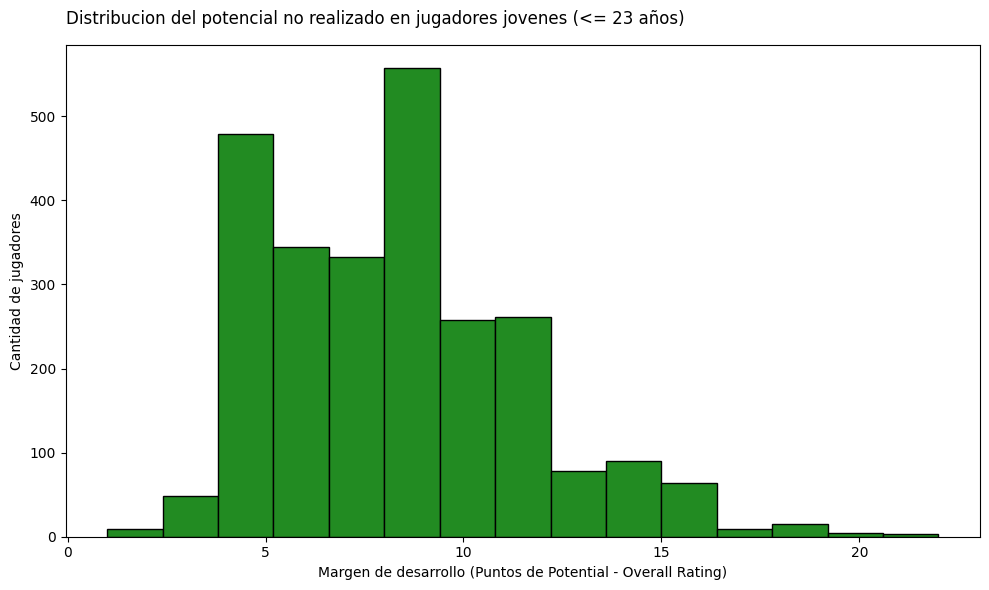

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definimos el color verde directamente
COLOR_PRINCIPAL = "#228B22"

# 2. Cargamos los datos
df_player_latest = pd.read_csv("df_player_latest.csv")

# 3. Convertimos las columnas de texto a formato datetime
df_player_latest["DATE"] = pd.to_datetime(df_player_latest["DATE"], errors="coerce").dt.floor("s")
df_player_latest["BIRTHDAY"] = pd.to_datetime(df_player_latest["BIRTHDAY"], errors="coerce").dt.floor("s")

# 4. Calculamos la nueva variable: el margen de desarrollo (gap)
df_dev = df_player_latest.copy()
df_dev["POTENTIAL_GAP"] = df_dev["POTENTIAL"] - df_dev["OVERALL_RATING"]

# 5. Calculamos la edad (Fecha de registro - Cumpleaños)
df_dev["AGE"] = (df_dev["DATE"] - df_dev["BIRTHDAY"]).dt.days // 365

# 6. Filtramos por edad (jugadores jovenes <= 23 años) y evitamos gaps negativos
df_dev = df_dev[df_dev["AGE"] <= 23]
df_dev = df_dev[df_dev["POTENTIAL_GAP"] >= 0]

# 7. Graficamos el histograma
fig, ax = plt.subplots(figsize = (10, 6))

ax.hist(df_dev["POTENTIAL_GAP"], bins = 15, color = COLOR_PRINCIPAL, edgecolor = "black")

# Titulos y etiquetas
ax.set_title("Distribucion del potencial no realizado en jugadores jovenes (<= 23 años)", loc = "left", pad = 15)
ax.set_xlabel("Margen de desarrollo (Puntos de Potential - Overall Rating)")
ax.set_ylabel("Cantidad de jugadores")

fig.tight_layout()
plt.show()

### Analisis del grafico

Al observar el histograma de la variable calculada `POTENTIAL_GAP`, se nota claramente que la distribución está sesgada hacia la izquierda. Esto nos indica que lo más común es encontrar jugadores jóvenes que tienen un margen de mejora relativamente bajo o estándar, agrupándose la gran mayoría entre 0 y 6 puntos de crecimiento estimado.

Por otro lado, la cola derecha de la distribución muestra que es bastante raro encontrar jugadores con un margen de desarrollo muy alto (mayor a 10 o 12 puntos). Para el insight esperado de un scouter o director técnico, la conclusión es contundente: los prospectos con un gran gap de crecimiento son sumamente escasos. Si el equipo identifica a un talento joven con un margen de mejora superior a los 10 puntos, este representa una oportunidad de inversión poco común dentro de la base de datos y debería ser prioridad para scoutear y fichar.

## Analisis 08: Atributos que separan a los jugadores mas prometedores

- Pregunta: Que atributos diferencian mejor a los jugadores mas prometedores del resto?
- Que se calcula?: La diferencia de promedios por atributo entre un grupo de alto potencial y un grupo de referencia.
- Datos a usar: df_player_latest.csv
- Grafico: Grafico boxplot.
- Precauciones: Definir bien el grupo de alto potencial; comparar jugadores de edades parecidas (<= 23 años); no usar demasiados atributos a la vez.
- Como identificar si el resultado es relevante?: Si algunos atributos sobresalen con diferencias claras sobre los demas.
- Insight esperado: Identificar que atributos conviene priorizar al buscar talento joven.

Para asegurar una comparación justa, primero calcularemos la edad y filtraremos la base a jugadores de 23 años o menos. Luego, definiremos al grupo de "Alta Promesa" como aquellos que se encuentran en el Top 10% de mayor potencial (`POTENTIAL`), y los compararemos contra el resto de los jóvenes evaluando una lista de 10 atributos clave (técnicos, físicos y mentales).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definimos los colores (rosa para las promesas, gris para el resto)
PALETA = {"Alta Promesa (Top 10%)": "#CC3AA2", "Resto de Jovenes": "#B0C4DE"}

# 2. Cargamos los datos
df_player = pd.read_csv("df_player_latest.csv")

# 3. Convertimos fechas y calculamos la edad
df_player["DATE"] = pd.to_datetime(df_player["DATE"], errors="coerce").dt.floor("s")
df_player["BIRTHDAY"] = pd.to_datetime(df_player["BIRTHDAY"], errors="coerce").dt.floor("s")
df_player["AGE"] = (df_player["DATE"] - df_player["BIRTHDAY"]).dt.days // 365

# 4. Filtramos para comparar solo jugadores jovenes (<= 23 años)
df_young = df_player[df_player["AGE"] <= 23].copy()

# 5. Definimos el umbral del Top 10% de potencial
umbral_top = df_young["POTENTIAL"].quantile(0.90)

# Creamos una nueva columna para clasificar a los jugadores
df_young["PROSPECT_LEVEL"] = np.where(df_young["POTENTIAL"] >= umbral_top, 
                                      "Alta Promesa (Top 10%)", 
                                      "Resto de Jovenes")

# 6. Seleccionamos 6 atributos clave para que el Boxplot sea legible
atributos = ['BALL_CONTROL', 'VISION', 'REACTIONS', 'SHORT_PASSING', 'SPRINT_SPEED', 'STAMINA']

# Transformamos los datos a formato largo (melt) para que Seaborn pueda agruparlos
df_melted = df_young.melt(id_vars=["PROSPECT_LEVEL"], value_vars=atributos, 
                          var_name="ATRIBUTO", value_name="PUNTUACION")

# Limpiamos los nombres de los atributos quitando el guion bajo
df_melted["ATRIBUTO"] = df_melted["ATRIBUTO"].str.replace("_", " ")

# Traducimos los nombres al español
traducciones = {
    'BALL CONTROL': 'Control de Balón',
    'VISION': 'Visión',
    'REACTIONS': 'Reacciones',
    'SHORT PASSING': 'Pase Corto',
    'SPRINT SPEED': 'Velocidad Sprint',
    'STAMINA': 'Resistencia'
}
df_melted["ATRIBUTO"] = df_melted["ATRIBUTO"].replace(traducciones)

# 7. Construimos y mostramos la grafica
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df_melted, x="ATRIBUTO", y="PUNTUACION", hue="PROSPECT_LEVEL", palette=PALETA, ax=ax)

# Titulos y etiquetas
ax.set_title("Distribucion de Atributos: Altas Promesas vs Resto de Jovenes (<= 23 años)", loc="left", pad=15)
ax.set_xlabel("Atributos Evaluados")
ax.set_ylabel("Puntuacion del Atributo")

# Movemos la leyenda para que no tape los datos
sns.move_legend(ax, "lower right", title="Nivel de Prospecto")
ax.grid(axis='y', linestyle='--', alpha=0.6)

fig.tight_layout()
plt.show()

### Analisis del grafico

En este gráfico de barras horizontales evaluamos qué atributos específicos marcan la mayor diferencia entre un joven "promedio" y una "alta promesa" (Top 10% de potencial). 

El resultado revela un insight clave para las estrategias de scouting: **las diferencias más grandes no suelen estar en los atributos físicos puros** (como la aceleración o la velocidad sprint), ya que muchos jugadores jóvenes promedio también son naturalmente rápidos. La verdadera brecha se encuentra en los **atributos técnicos y mentales** como `REACTIONS` (Reacciones), `BALL CONTROL` (Control de balón) y `VISION` (Visión).

**Insight para el Director Técnico / Scouter:**
Al buscar talento joven, los reclutadores no deben dejarse deslumbrar únicamente por la velocidad o el físico del jugador, pues estas variables no garantizan un potencial de élite. En su lugar, se debe priorizar el scouting de jugadores jóvenes que ya demuestren una excelente técnica base (control y pase corto) y una lectura de juego avanzada (reacciones y visión), ya que estos son los rasgos estadísticos que verdaderamente separan a los futuros jugadores de clase mundial del resto.

## Analisis 10: Relacion entre edad y rendimiento promedio del jugador

- Pregunta: En que edades se observa el mejor nivel promedio de los jugadores?
- Que se calcula?: El promedio de overall_rating por edad.
- Datos a usar: df_player_latest.csv
- Grafico: Grafico de lineas.
- Precauciones: Calcular bien la edad matemática; revisar y filtrar edades con muy pocos jugadores para evitar ruido estadístico.
- Como identificar si el resultado es relevante?: Si se observa una tendencia clara de crecimiento, pico de rendimiento y posible descenso con la edad.
- Insight esperado: Entender en que etapa de edad se concentra el mejor rendimiento promedio.

Para este análisis, calcularemos la edad de los jugadores y agruparemos la base de datos para obtener el promedio de nivel (`OVERALL_RATING`) en cada año de vida. Como medida de precaución, se aplicará un filtro para excluir aquellas edades que tengan muy pocos registros, logrando así una línea de tendencia limpia, representativa y libre de valores atípicos engañosos.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definimos el color principal
COLOR_PRINCIPAL = "#521FB8"

# 2. Cargamos los datos (Recuerda poner tu ruta completa con la r"..." si Jupyter se pierde)
df_player = pd.read_csv("df_player_latest.csv")

# 3. Convertimos fechas y calculamos la edad
df_player["DATE"] = pd.to_datetime(df_player["DATE"], errors="coerce").dt.floor("s")
df_player["BIRTHDAY"] = pd.to_datetime(df_player["BIRTHDAY"], errors="coerce").dt.floor("s")
df_player["AGE"] = (df_player["DATE"] - df_player["BIRTHDAY"]).dt.days // 365

# 4. Limpieza de ruido: Contamos cuántos jugadores hay por cada edad
conteo_edades = df_player.groupby("AGE").size()

# Nos quedamos solo con edades que tengan al menos 10 jugadores registrados
# para evitar que un solo jugador muy viejo o muy joven altere el promedio
edades_validas = conteo_edades[conteo_edades >= 10].index
df_linea = df_player[df_player["AGE"].isin(edades_validas)]

# 5. Calculamos el promedio del nivel (OVERALL_RATING) por cada edad
promedio_por_edad = df_linea.groupby("AGE")["OVERALL_RATING"].mean()

# 6. Construimos y mostramos la grafica
fig, ax = plt.subplots(figsize=(10, 6))

# Grafico de lineas con marcadores ('o') en cada punto para que se vea claro
ax.plot(promedio_por_edad.index, promedio_por_edad.values, marker='o', 
        color=COLOR_PRINCIPAL, linewidth=2.5, markersize=6)

# Titulos y etiquetas
ax.set_title("Nivel Promedio de los Jugadores segun su Edad (Overall Rating)", loc="left", pad=15)
ax.set_xlabel("Edad (Años)")
ax.set_ylabel("Nivel Promedio (Overall Rating)")

# Agregamos una cuadricula sutil para facilitar la lectura de los puntos
ax.grid(linestyle='--', alpha=0.6)

fig.tight_layout()
plt.show()

### Analisis del grafico

Al observar la curva de tendencia en este gráfico de líneas, podemos identificar con claridad las tres etapas biológicas y deportivas que definen la carrera de un futbolista profesional:

1. **Fase de crecimiento:** Desde las edades más tempranas (16-18 años), la línea muestra una pendiente ascendente constante y pronunciada. Es en esta etapa donde los jugadores adquieren madurez táctica, experiencia y desarrollo físico.
2. **El "Prime" o Pico de Rendimiento:** La curva alcanza su punto más alto y forma una "meseta" típica entre los 27 y los 31 años. Es en esta franja donde el jugador encuentra el balance perfecto: combina su máxima experiencia futbolística con un físico aún en óptimas condiciones.
3. **Fase de declive:** A partir de los 32 años, la línea comienza un descenso evidente, reflejando la pérdida natural de capacidades físicas (como velocidad, explosividad o resistencia) que termina por afectar la valoración general.

**Insight para el Director Técnico / Directiva:**
Este gráfico dicta la lógica financiera y deportiva para armar una plantilla equilibrada. Si el equipo busca éxito inmediato para competir por un campeonato, debe apostar por jugadores en su "prime" (27-30 años), sabiendo que su costo será el más elevado. En cambio, si la directiva busca construir un proyecto a mediano plazo y generar plusvalía, la inversión debe ir hacia la fase de crecimiento (20-23 años), adquiriendo talento cuyo rendimiento y valor de mercado estadísticamente irán a la alza.